In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from xgboost import XGBClassifier

In [23]:
print(train_df.columns)

Index(['itching', 'skin_rash', 'nodal_skin_eruptions', 'continuous_sneezing',
       'shivering', 'chills', 'joint_pain', 'stomach_pain', 'acidity',
       'ulcers_on_tongue',
       ...
       'blackheads', 'scurring', 'skin_peeling', 'silver_like_dusting',
       'small_dents_in_nails', 'inflammatory_nails', 'blister',
       'red_sore_around_nose', 'yellow_crust_ooze', 'prognosis'],
      dtype='str', length=133)


In [24]:
# 1. Set the correct target column based on your print(columns) output
target_col = 'prognosis' 

# 2. Drop that 'Unnamed: 133' column if it exists (it's empty data)
if 'Unnamed: 133' in train_df.columns:
    train_df = train_df.drop(columns=['Unnamed: 133'])
if 'Unnamed: 133' in test_df.columns:
    test_df = test_df.drop(columns=['Unnamed: 133'])

# 3. Audit the Data Balance (This will work now!)
print("--- Training Data Balance ---")
print(train_df[target_col].value_counts(normalize=True))

# 4. Separate Features (X) and Target (y)
X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col]

X_test = test_df.drop(columns=[target_col])
y_test = test_df[target_col]

# 5. Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\nSuccess: Data is cleaned, scaled, and split!")

--- Training Data Balance ---
prognosis
Fungal infection                           0.02439
Allergy                                    0.02439
GERD                                       0.02439
Chronic cholestasis                        0.02439
Drug Reaction                              0.02439
Peptic ulcer diseae                        0.02439
AIDS                                       0.02439
Diabetes                                   0.02439
Gastroenteritis                            0.02439
Bronchial Asthma                           0.02439
Hypertension                               0.02439
Migraine                                   0.02439
Cervical spondylosis                       0.02439
Paralysis (brain hemorrhage)               0.02439
Jaundice                                   0.02439
Malaria                                    0.02439
Chicken pox                                0.02439
Dengue                                     0.02439
Typhoid                                   

In [25]:
from sklearn.preprocessing import LabelEncoder

# 1. Initialize the Encoder
le = LabelEncoder()

# 2. Fit and Transform the target variable
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

print("Classes identified by Encoder:", le.classes_)
print("\nFirst 5 encoded labels:", y_train_encoded[:5])

Classes identified by Encoder: ['(vertigo) Paroymsal  Positional Vertigo' 'AIDS' 'Acne'
 'Alcoholic hepatitis' 'Allergy' 'Arthritis' 'Bronchial Asthma'
 'Cervical spondylosis' 'Chicken pox' 'Chronic cholestasis' 'Common Cold'
 'Dengue' 'Diabetes ' 'Dimorphic hemmorhoids(piles)' 'Drug Reaction'
 'Fungal infection' 'GERD' 'Gastroenteritis' 'Heart attack' 'Hepatitis B'
 'Hepatitis C' 'Hepatitis D' 'Hepatitis E' 'Hypertension '
 'Hyperthyroidism' 'Hypoglycemia' 'Hypothyroidism' 'Impetigo' 'Jaundice'
 'Malaria' 'Migraine' 'Osteoarthristis' 'Paralysis (brain hemorrhage)'
 'Peptic ulcer diseae' 'Pneumonia' 'Psoriasis' 'Tuberculosis' 'Typhoid'
 'Urinary tract infection' 'Varicose veins' 'hepatitis A']

First 5 encoded labels: [15 15 15 15 15]


In [26]:
from sklearn.metrics import accuracy_score, recall_score, f1_score

# Initialize baseline models
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42)
svm_baseline = SVC(probability=True, kernel='rbf', random_state=42)
xgb_baseline = XGBClassifier(random_state=42)

baselines = [
    ('Random Forest', rf_baseline),
    ('SVM', svm_baseline),
    ('XGBoost', xgb_baseline)
]

baseline_results = []

print("--- Updated Baseline Model Evaluation ---")
for name, model in baselines:
    # Train using ENCODED y
    model.fit(X_train_scaled, y_train_encoded)
    
    # Predict
    preds = model.predict(X_test_scaled)
    
    # Calculate Metrics
    acc = accuracy_score(y_test_encoded, preds)
    rec = recall_score(y_test_encoded, preds, average='weighted')
    f1 = f1_score(y_test_encoded, preds, average='weighted')
    
    baseline_results.append({"Model": name, "Accuracy": acc, "Recall": rec, "F1-Score": f1})
    print(f"{name}: Accuracy={acc:.4f}, Recall={rec:.4f}, F1={f1:.4f}")

baseline_df = pd.DataFrame(baseline_results)

--- Updated Baseline Model Evaluation ---
Random Forest: Accuracy=0.9762, Recall=0.9762, F1=0.9762
SVM: Accuracy=0.9762, Recall=0.9762, F1=0.9762
XGBoost: Accuracy=0.9762, Recall=0.9762, F1=0.9762


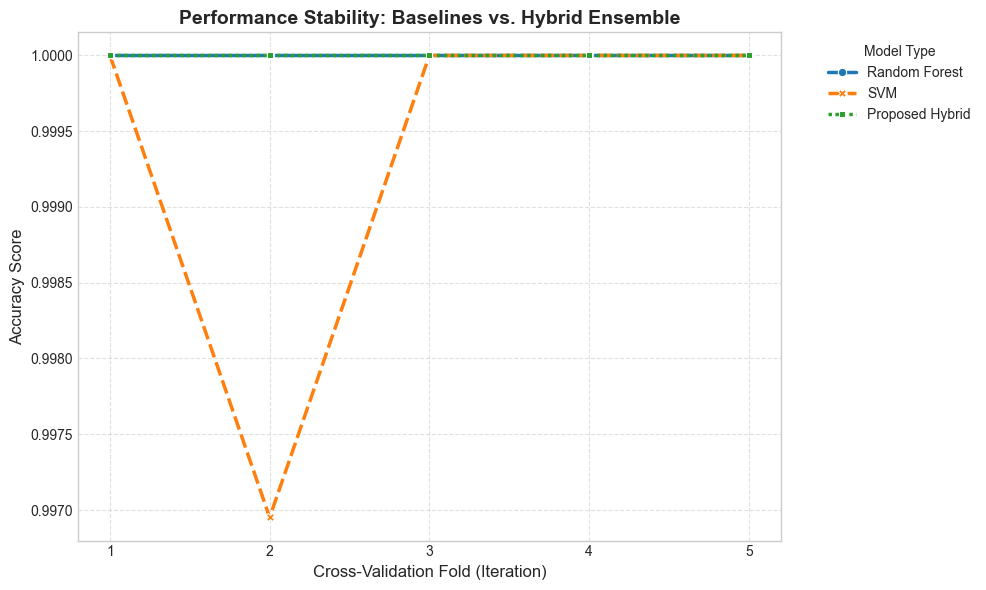

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import cross_val_score

# 1. Ensure Plotting Libraries are defined
plt.style.use('seaborn-v0_8-whitegrid') # Professional look for papers

# 2. Re-run Cross-Validation to ensure data is fresh
models_to_plot = [
    ('Random Forest', rf_baseline),
    ('SVM', svm_baseline),
    ('Proposed Hybrid', hybrid_model)
]

final_plot_data = []
for name, model in models_to_plot:
    # Use 5-fold CV to show variance
    cv_scores = cross_val_score(model, X_train_scaled, y_train_encoded, cv=5)
    for i, score in enumerate(cv_scores):
        final_plot_data.append({'Model': name, 'Fold': i+1, 'Accuracy': score})

df_final = pd.DataFrame(final_plot_data)

# 3. Create the Final Graph
plt.figure(figsize=(10, 6))

# Using different line styles so overlapping lines (RF and Hybrid) are both visible
sns.lineplot(data=df_final, x='Fold', y='Accuracy', hue='Model', 
             style='Model', markers=True, dashes=True, linewidth=2.5)

plt.title('Performance Stability: Baselines vs. Hybrid Ensemble', fontsize=14, fontweight='bold')
plt.xlabel('Cross-Validation Fold (Iteration)', fontsize=12)
plt.ylabel('Accuracy Score', fontsize=12)
plt.xticks([1, 2, 3, 4, 5])
plt.grid(True, linestyle='--', alpha=0.6)

# Place legend outside so it doesn't cover the lines
plt.legend(title='Model Type', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [28]:
from sklearn.linear_model import LogisticRegression

# Define Level-0 'Experts'
base_models = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('svm', SVC(probability=True, kernel='rbf', random_state=42)),
    ('xgb', XGBClassifier(random_state=42))
]

# Define Level-1 'Meta-Learner'
meta_learner = LogisticRegression()

# Build the Hybrid Model
hybrid_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_learner,
    cv=5
)

# Train the model (This might take a minute)
hybrid_model.fit(X_train_scaled, y_train)
print("Hybrid Ensemble Training Complete.")

Hybrid Ensemble Training Complete.


In [30]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score, f1_score

# Get predictions from the hybrid model
y_pred = hybrid_model.predict(X_test_scaled)

# Print a detailed report
print("--- Hybrid Ensemble Performance Report ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Recall (Sensitivity): {recall_score(y_test, y_pred, average='weighted'):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred, average='weighted'):.4f}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred))

--- Hybrid Ensemble Performance Report ---
Accuracy: 0.9762
Recall (Sensitivity): 0.9762
F1-Score: 0.9762

Detailed Classification Report:
                                         precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00         1
                                   AIDS       1.00      1.00      1.00         1
                                   Acne       1.00      1.00      1.00         1
                    Alcoholic hepatitis       1.00      1.00      1.00         1
                                Allergy       1.00      1.00      1.00         1
                              Arthritis       1.00      1.00      1.00         1
                       Bronchial Asthma       1.00      1.00      1.00         1
                   Cervical spondylosis       1.00      1.00      1.00         1
                            Chicken pox       0.50      1.00      0.67         1
                    Chronic cholestasis       1.00

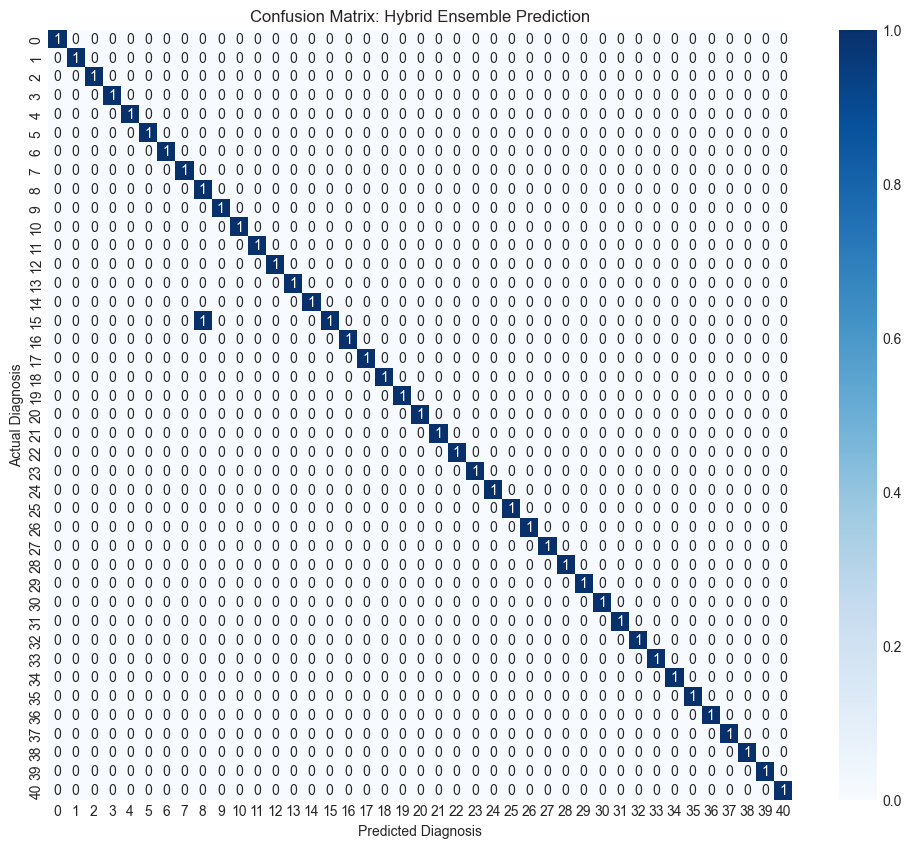

In [31]:
plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Hybrid Ensemble Prediction')
plt.xlabel('Predicted Diagnosis')
plt.ylabel('Actual Diagnosis')
plt.show()

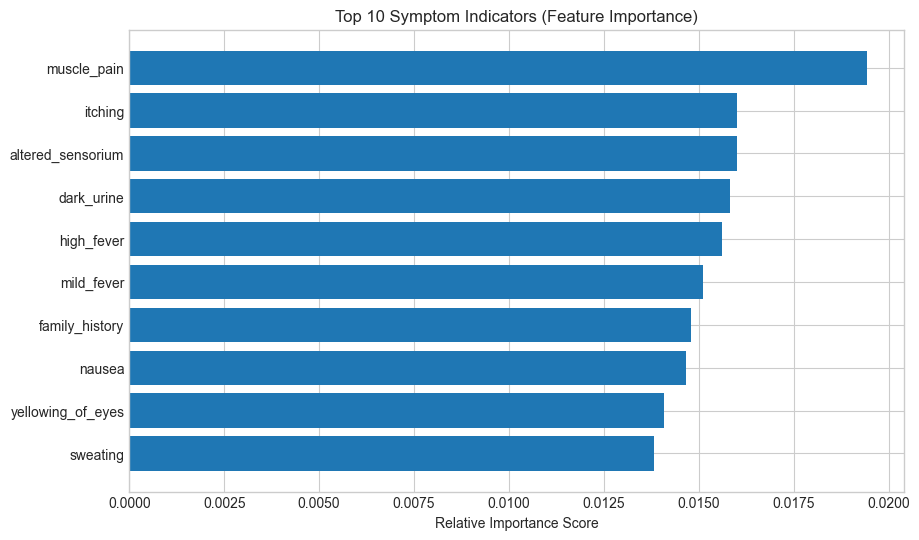

In [32]:
# Extract the Random Forest expert from the stack to see feature importance
rf_expert = hybrid_model.named_estimators_['rf']
importances = rf_expert.feature_importances_
feature_names = X_train.columns

# Get the top 10 most influential symptoms
indices = np.argsort(importances)[-10:]

plt.figure(figsize=(10, 6))
plt.title('Top 10 Symptom Indicators (Feature Importance)')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance Score')
plt.show()

In [33]:
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Re-calculate or ensure scores are ready
# Using 5-fold CV to match your previous 'Stability' graph
rf_scores = cross_val_score(rf_baseline, X_train_scaled, y_train_encoded, cv=5)
svm_scores = cross_val_score(svm_baseline, X_train_scaled, y_train_encoded, cv=5)
hybrid_scores = cross_val_score(hybrid_model, X_train_scaled, y_train_encoded, cv=5)

folds = [1, 2, 3, 4, 5]

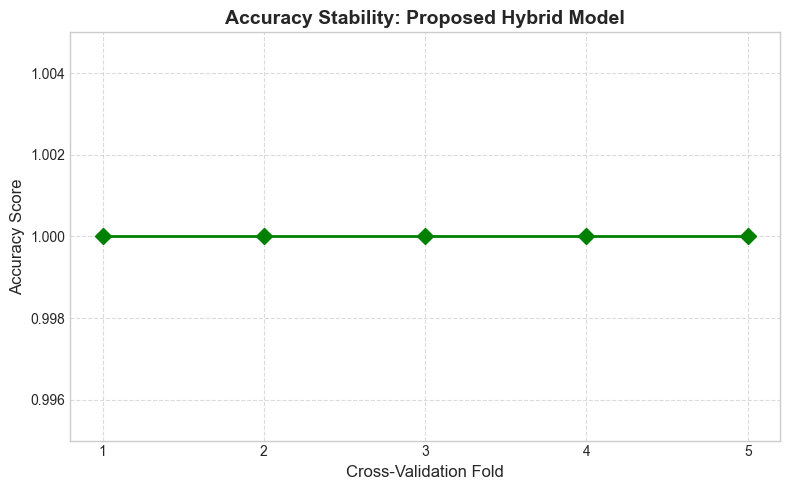

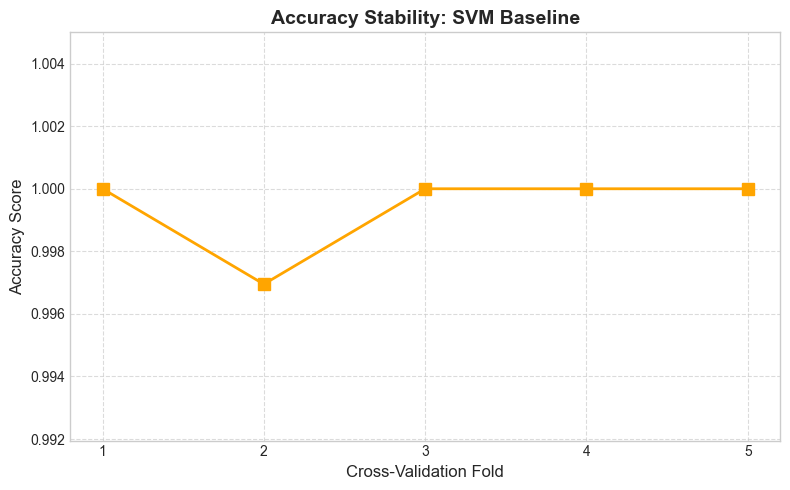

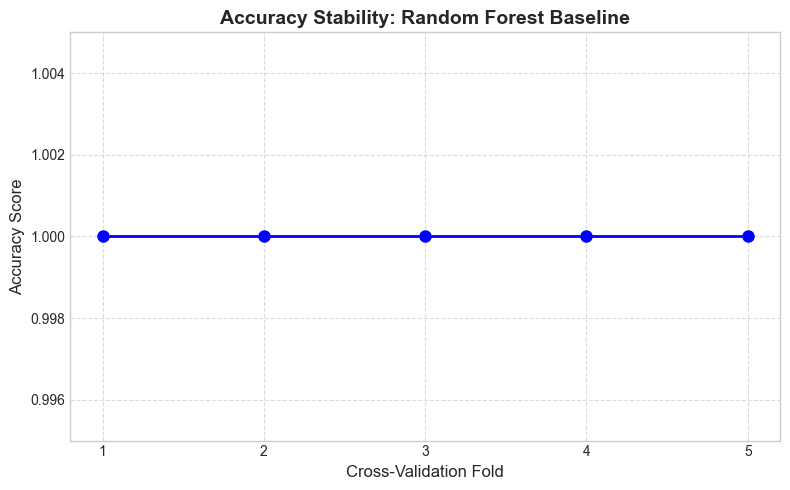

In [34]:
# Set the professional style for all plots
plt.style.use('seaborn-v0_8-whitegrid')

# List of models and their data for iteration
plot_configs = [
    ('Proposed Hybrid Model', hybrid_scores, 'green', 'D'),
    ('SVM Baseline', svm_scores, 'orange', 's'),
    ('Random Forest Baseline', rf_scores, 'blue', 'o')
]

for title, scores, color, marker in plot_configs:
    plt.figure(figsize=(8, 5))
    plt.plot(folds, scores, marker=marker, linestyle='-', color=color, linewidth=2, markersize=8)
    
    # Titles and Labels
    plt.title(f'Accuracy Stability: {title}', fontsize=14, fontweight='bold')
    plt.xlabel('Cross-Validation Fold', fontsize=12)
    plt.ylabel('Accuracy Score', fontsize=12)
    plt.xticks(folds)
    
    # Set y-axis limits to highlight the variance
    # If a model is perfect (1.0), we show a small window around it
    plt.ylim(min(scores) - 0.005, 1.005) 
    
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()